<a href="https://colab.research.google.com/github/batrataj/NEXUS-SEC/blob/main/notebooks/3_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
import pandas as pd

url = "https://raw.githubusercontent.com/batrataj/NEXUS-SEC/main/data/clean_network_data.xlsx"

df = pd.read_excel(url)

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,BENIGN


## Attack Distribution
This visualization shows how many records belong to each network traffic type.
Understanding this distribution helps identify whether the dataset contains more normal traffic or malicious traffic.

Cybersecurity datasets often contain significantly more normal traffic than attack traffic, which can lead to class imbalance.

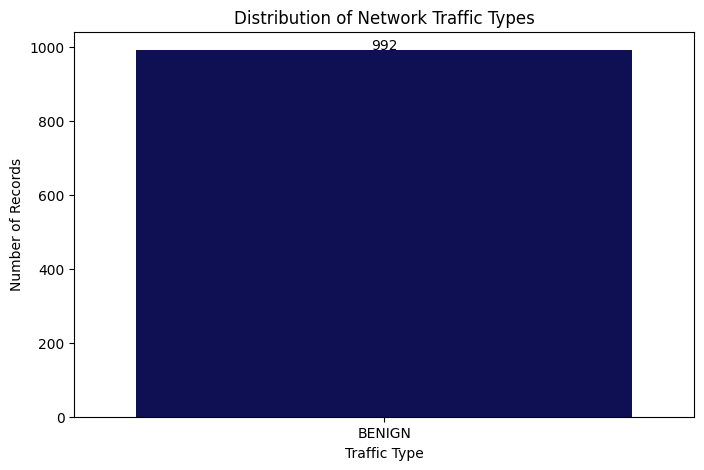

In [42]:

import matplotlib.pyplot as plt
import seaborn as sns

attack_counts = df['Label'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=attack_counts.index,
    y=attack_counts.values,
    color="#030460"
)

plt.title("Distribution of Network Traffic Types")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")

for i, v in enumerate(attack_counts.values):
    plt.text(i, v + 3, str(v), ha='center')

plt.show()



The chart shows that most of the network traffic is labeled as **BENIGN**, representing normal network activity.

Only a small portion of the dataset corresponds to attack traffic. This indicates that the dataset is **highly imbalanced**, which is common in cybersecurity datasets.

Such imbalance can affect machine learning models and may require techniques such as resampling or class balancing in later stages of the analysis.

## Flow Duration Distribution
This analysis examines how long network connections typically last.

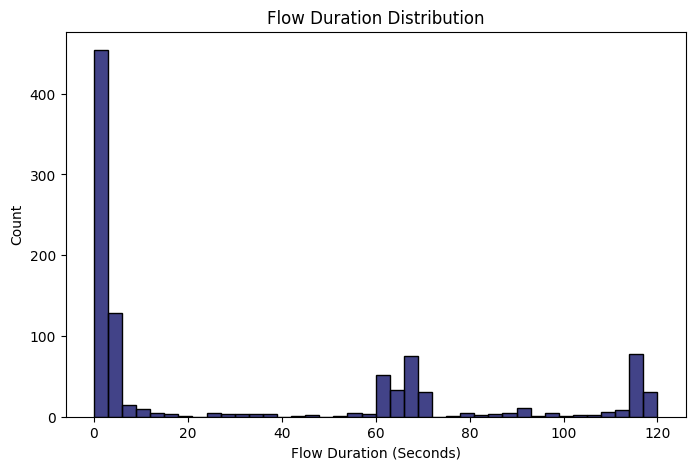

In [63]:
plt.figure(figsize=(8,5))

flow_seconds = df['Flow Duration'] / 1000000

sns.histplot(
    flow_seconds,
    bins=40,
    color="#030460"
)

plt.title("Flow Duration Distribution")
plt.xlabel("Flow Duration (Seconds)")
plt.ylabel("Count")

plt.show()

Flow duration represents the length of time a network connection remains active.

The histogram shows that most connections have very short durations, indicating that many network interactions complete quickly. However, there are smaller groups of longer connections around 60–70 seconds and near 120 seconds, which may represent longer data transfers or sustained communication sessions.

## Flow Duration by Traffic Type
This visualization compares connection duration across traffic types.

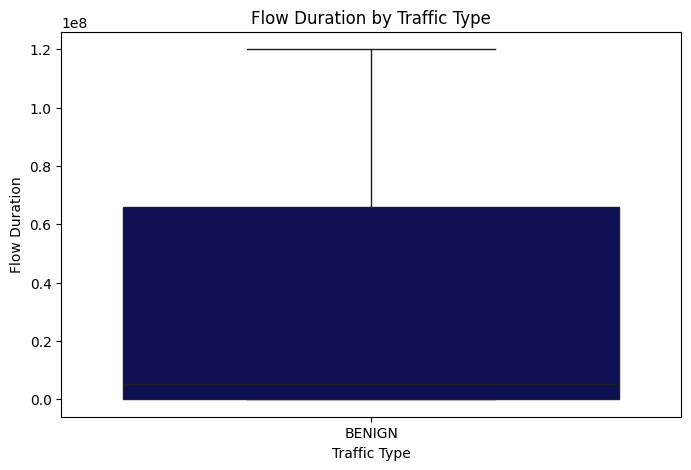

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Label'],
    y=df['Flow Duration'],
    color="#030460"
)

plt.title("Flow Duration by Traffic Type")
plt.xlabel("Traffic Type")
plt.ylabel("Flow Duration")

plt.show()

This comparison helps identify whether attack traffic behaves differently from normal traffic.
Certain attacks may generate shorter or longer connections depending on their behavior.

## Feature Correlation
Correlation analysis shows relationships between numerical features in the dataset.

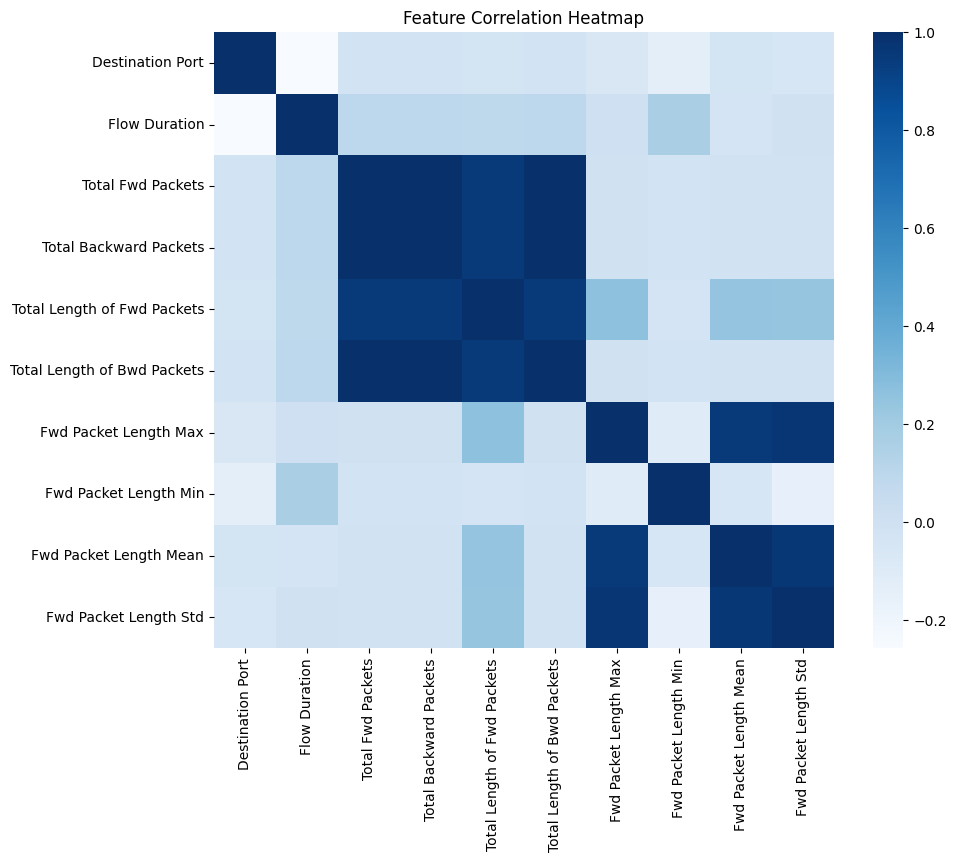

In [44]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="Blues"
)

plt.title("Feature Correlation Heatmap")

plt.show()



The heatmap shows how different network traffic features are related to each other.
Features with stronger correlations may represent similar network behaviors.
This analysis helps identify important variables and can improve feature selection when building machine learning models for detecting malicious network activity.

## Most Used Destination Ports

This visualization shows the most frequently used destination ports in the dataset.

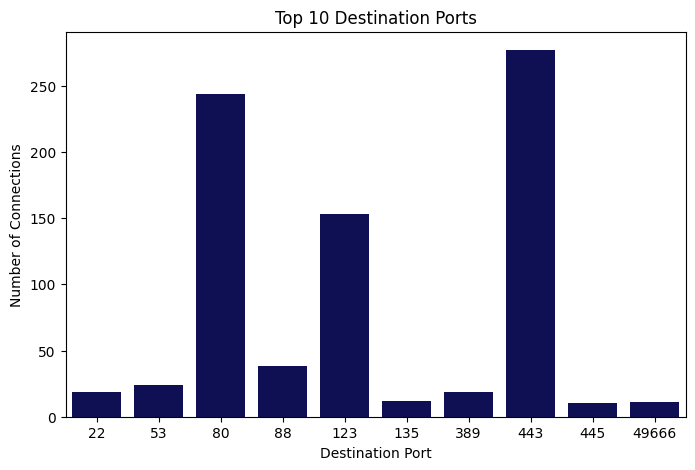

In [51]:
top_ports = df['Destination Port'].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_ports.index,
    y=top_ports.values,
    color="#030460"
)

plt.title("Top 10 Destination Ports")
plt.xlabel("Destination Port")
plt.ylabel("Number of Connections")

plt.show()



The visualization highlights the most frequently used destination ports in the dataset.

Common ports such as 80 (HTTP) and 443 (HTTPS) often appear frequently because they are used for web communication.

Understanding port usage helps identify which services dominate the network traffic.

## Packet Direction Comparison

This visualization compares the average number of forward and backward packets.

/tmp/ipykernel_567/807867777.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


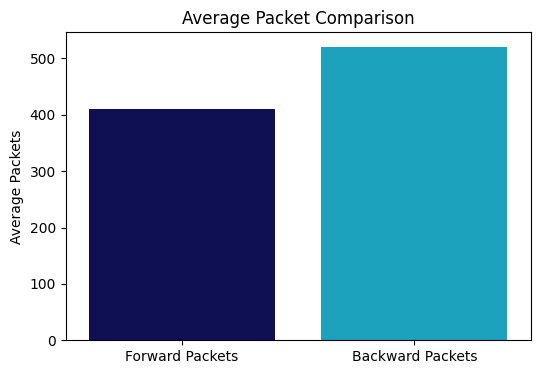

In [52]:
avg_fwd = df['Total Fwd Packets'].mean()
avg_bwd = df['Total Backward Packets'].mean()

plt.figure(figsize=(6,4))

sns.barplot(
    x=["Forward Packets","Backward Packets"],
    y=[avg_fwd, avg_bwd],
    palette=["#030460","#02B4D8"]
)

plt.title("Average Packet Comparison")
plt.ylabel("Average Packets")

plt.show()



The chart compares the average number of forward and backward packets in the network traffic.

The results show that the average number of backward packets is slightly higher than forward packets, indicating that responses from the destination are slightly larger than the requests sent from the source.

This behavior can reflect typical client-server communication patterns in network traffic.

## Packet Size Comparison

This visualization compares the average size of forward packets.

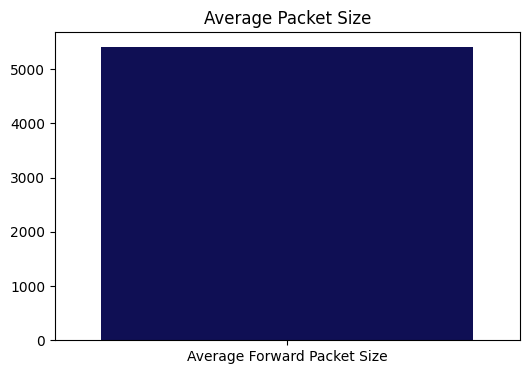

In [53]:
avg_len = df['Total Length of Fwd Packets'].mean()

plt.figure(figsize=(6,4))

sns.barplot(
    x=["Average Forward Packet Size"],
    y=[avg_len],
    color="#030460"
)

plt.title("Average Packet Size")

plt.show()



The chart shows the average size of forward packets transmitted in the network traffic.

Packet size helps indicate how much data is transferred during communication sessions. Larger packet sizes may represent heavier data exchanges such as file transfers or streaming services.

## Packet Direction Ratio

This chart shows the proportion of forward and backward packets in the network traffic.

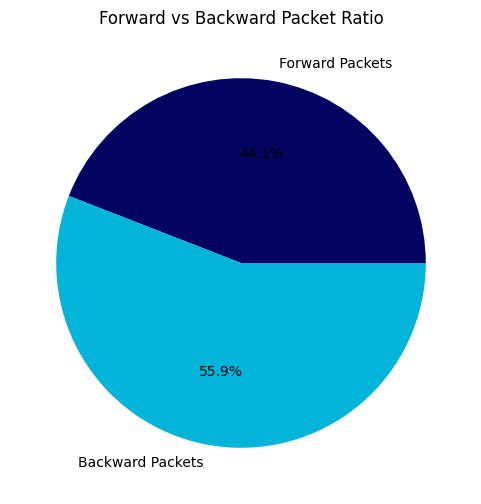

In [55]:
fwd_packets = df['Total Fwd Packets'].sum()
bwd_packets = df['Total Backward Packets'].sum()

plt.figure(figsize=(6,6))

plt.pie(
    [fwd_packets, bwd_packets],
    labels=["Forward Packets", "Backward Packets"],
    autopct='%1.1f%%',
    colors=["#030460", "#02B4D8"]
)

plt.title("Forward vs Backward Packet Ratio")

plt.show()



The pie chart shows the proportion of forward and backward packets in the dataset.

This helps understand the communication balance between sending and receiving data within the network traffic.

## Flow Duration vs Packet Size Trend

This visualization explores the relationship between connection duration and packet size in the network traffic dataset.

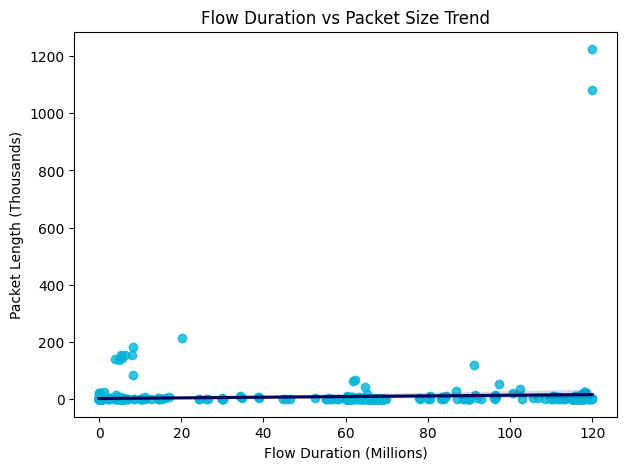

In [58]:
plt.figure(figsize=(7,5))

sns.regplot(
    x=df['Flow Duration']/1000000,
    y=df['Total Length of Fwd Packets']/1000,
    scatter_kws={"color":"#02B4D8"},
    line_kws={"color":"#030460"}
)

plt.title("Flow Duration vs Packet Size Trend")
plt.xlabel("Flow Duration (Millions)")
plt.ylabel("Packet Length (Thousands)")

plt.show()



The scatter plot shows how packet size varies with the duration of network connections.

Most network connections have short durations and relatively small packet sizes, which indicates lightweight communication. However, a few connections show significantly larger packet sizes, suggesting heavier data transfers within the network.

## Packet Length Distribution

This visualization shows the distribution of forward packet lengths across network connections. Understanding packet size distribution helps identify common data transfer patterns within the network traffic.

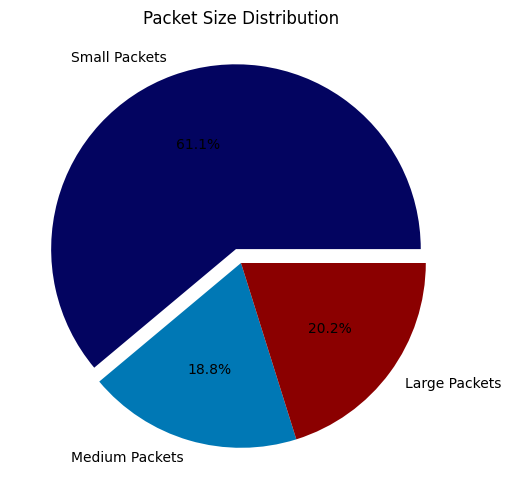

In [61]:
small_packets = (df['Total Length of Fwd Packets'] < 500).sum()
medium_packets = ((df['Total Length of Fwd Packets'] >= 500) & (df['Total Length of Fwd Packets'] < 1500)).sum()
large_packets = (df['Total Length of Fwd Packets'] >= 1500).sum()

sizes = [small_packets, medium_packets, large_packets]

labels = [
    "Small Packets",
    "Medium Packets",
    "Large Packets"
]

colors = [
    "#030460",
    "#0078B5",
    "#8B0000"
]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    explode=(0.08,0,0)
)

plt.title("Packet Size Distribution")

plt.show()



The pie chart illustrates the distribution of packet sizes within the network traffic dataset.

Most packets fall into the small packet category, representing the majority of network communications. This indicates that typical network activities involve lightweight data exchanges.

Medium packets appear less frequently, while large packets account for a noticeable portion of the traffic, suggesting that some connections involve larger data transfers.